## 1. Importación de librerías

In [130]:
import pandas as pd #Leer y manipular el CSV
import numpy as np  #Cálculos numéricos
import matplotlib.pyplot as plt  #Crear gráficos
import seaborn as sns  #Gráficos estadísticos

from sklearn.tree import DecisionTreeRegressor #Machine Learning
from sklearn.preprocessing import StandardScaler #Machine Learning

import torch  #Deep Learning
import torch.nn as nn  #Creacion de nuestra red neuronal

In [131]:
data = pd.read_csv("hour.csv")

data["dteday"] = pd.to_datetime(data["dteday"])  #Convertimos el dato "dtoday" a dato tipo fecha
data = data.sort_values(["dteday", "hr"]).reset_index(drop=True) #Ordenamos

caract = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

x = data[caract]
y = data["cnt"] #CNT= Cantidad de bicicletas alquiladas, dato que queremos hallar

In [132]:
print(data.head()) #Procesamos y Validamos datos
print(data.info())
print(data.describe())

   instant     dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1 2011-01-01       1   0     1   0        0        6           0   
1        2 2011-01-01       1   0     1   1        0        6           0   
2        3 2011-01-01       1   0     1   2        0        6           0   
3        4 2011-01-01       1   0     1   3        0        6           0   
4        5 2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Co

In [133]:
print(x.shape)
print(y.shape)

(17379, 12)
(17379,)


In [134]:
frame = pd.DataFrame(x)
frame["target"] = y  # TARGET = Y = CNT = BICICLETAS 

print(frame.head())

   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   
2       1   0     1   2        0        6           0           1  0.22   
3       1   0     1   3        0        6           0           1  0.24   
4       1   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  target  
0  0.2879  0.81        0.0      16  
1  0.2727  0.80        0.0      40  
2  0.2727  0.80        0.0      32  
3  0.2879  0.75        0.0      13  
4  0.2879  0.75        0.0       1  


In [135]:
# Correlaciones_ Ayuda a identificar caracteristicas con mas influencia en la prediccion.
# print(data[caract + ["cnt"]].corr()["cnt"].sort_values(ascending=False))

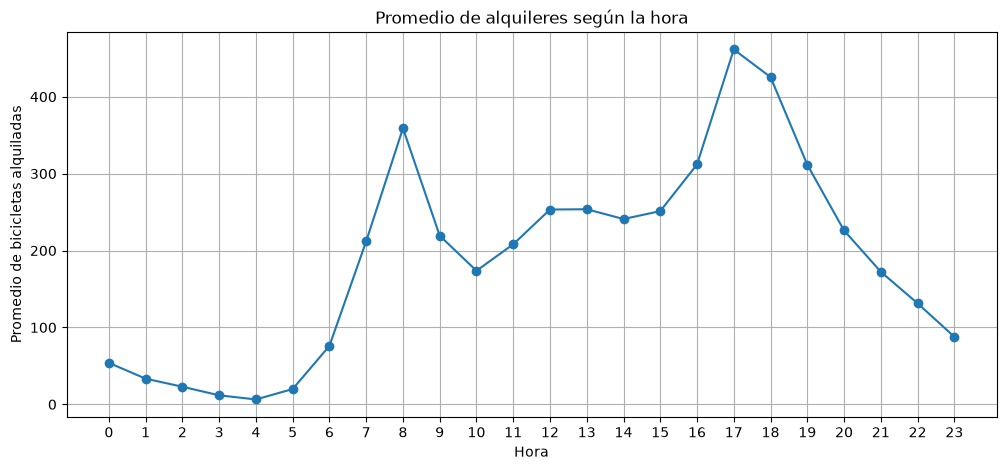

In [136]:
#MATERIAL DE APOYO
#GRAFICO HORA x BICICLETAS(cnt)

hour_mean = data.groupby("hr")["cnt"].mean()

plt.figure(figsize=(12, 5))
plt.plot(hour_mean.index, hour_mean.values, marker="o")
plt.xlabel("Hora")
plt.ylabel("Promedio de bicicletas alquiladas")
plt.title("Promedio de alquileres según la hora")
plt.xticks(range(24))
plt.grid()
plt.show()

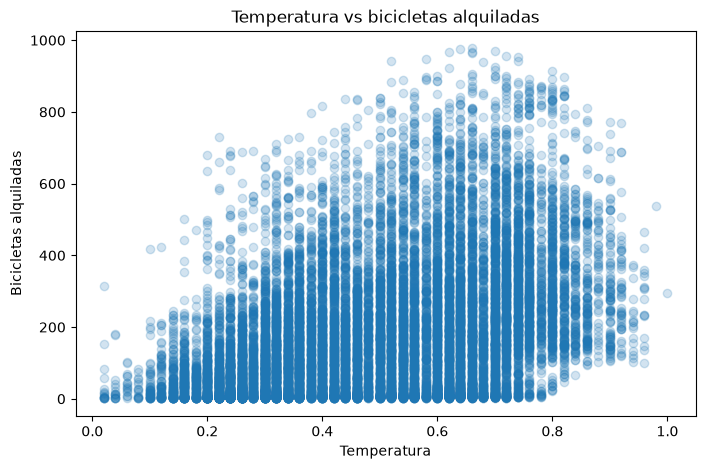

In [137]:
#MATERIAL DE APOYO

plt.figure(figsize=(8, 5))
plt.scatter(data["temp"], data["cnt"], alpha=0.2)
plt.xlabel("Temperatura")
plt.ylabel("Bicicletas alquiladas")
plt.title("Temperatura vs bicicletas alquiladas")
plt.show()

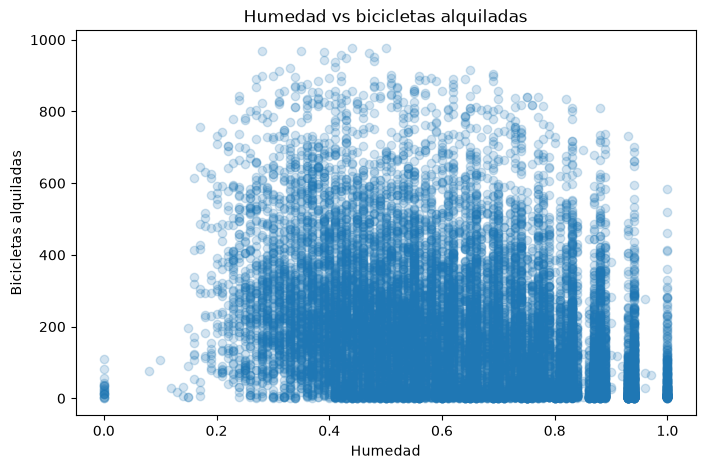

In [138]:
#MATERIAL DE APOYO

plt.figure(figsize=(8, 5))
plt.scatter(data["hum"], data["cnt"], alpha=0.2)
plt.xlabel("Humedad")
plt.ylabel("Bicicletas alquiladas")
plt.title("Humedad vs bicicletas alquiladas")
plt.show()

In [139]:
split = int(len(data) * 0.8)

train = data.iloc[:split]  #Adaptamos el code por el uso de variable de tipo date
test = data.iloc[split:]

x_train = train[caract]
y_train = train["cnt"]

x_test = test[caract]
y_test = test["cnt"]

print("X_train:", x_train.shape)
print("y_train:", y_train.shape)
print("X_test:", x_test.shape)
print("y_test:", y_test.shape)

X_train: (13903, 12)
y_train: (13903,)
X_test: (3476, 12)
y_test: (3476,)


In [140]:
model = DecisionTreeRegressor(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [141]:
muestra_indi = [[2,1,7,18,0,2,1,1,0.70,0.65,0.60,0.15]]
prediccion = model.predict(muestra_indi)

print("Predicción:")
print(prediccion)

Predicción:
[877.]


c:\Users\rtq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [142]:
muestra_indi = x_test.iloc[5].values.reshape(1, 12)

print("Muestra de prueba seleccionada")
print(muestra_indi)

prediccion = model.predict(muestra_indi)

print("Predicción del modelo")
print(prediccion)

print("Valor real de la muestra")
print(y_test.iloc[5])

Muestra de prueba seleccionada
[[ 3.      1.      8.     17.      0.      2.      1.      2.      0.78
   0.7424  0.62    0.1343]]
Predicción del modelo
[643.]
Valor real de la muestra
868


c:\Users\rtq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [143]:
comparacion = pd.DataFrame({
    "Real": y_test.values[:20],
    "Prediccion": y_pred[:20]
})

print(comparacion)

    Real  Prediccion
0    283       314.0
1    253       288.0
2    261       292.0
3    306       262.0
4    445       386.0
5    868       643.0
6    814       891.0
7    610       516.0
8    448       447.0
9    317       109.0
10   224       288.0
11   138       125.0
12    58        33.0
13    23        42.0
14     6        13.0
15     7         6.0
16     7        12.0
17    43        46.0
18   173       162.0
19   482       421.0


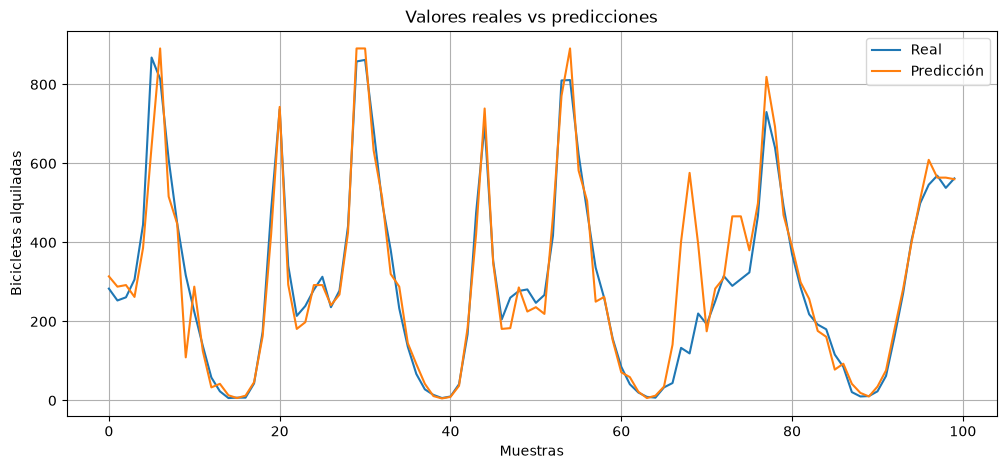

In [144]:
#MATERIAL DE APOYO
#Mapsa de comparaciones

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label="Real")
plt.plot(y_pred[:100], label="Predicción")
plt.xlabel("Muestras")
plt.ylabel("Bicicletas alquiladas")
plt.title("Valores reales vs predicciones")
plt.legend()
plt.grid()
plt.show()

In [145]:
#Escalado de datos para red neuronal

In [146]:
scaler = StandardScaler() #Normalizamos los datos

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Comvertimos datos a tensores
x_train_torch = torch.tensor(
    x_train_scaled,
    dtype=torch.float32
)

x_test_torch = torch.tensor(
    x_test_scaled,
    dtype=torch.float32
)

y_train_torch = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_torch = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

In [147]:
model_dl = nn.Sequential(
    nn.Linear(12, 144),
    nn.ReLU(),
    nn.Linear(144, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

loss_fn = nn.MSELoss() #Ayuda a calcular el error.

optimizer = torch.optim.Adam(  #Ayuda a optimizar el proceso modificando pesos 
    model_dl.parameters(),
    lr=0.001
)

In [148]:
for epoch in range(100):

    salida = model_dl(x_train_torch)

    loss = loss_fn( #Calculamos el error.
        salida,
        y_train_torch
    )

    optimizer.zero_grad() #limpiamos los gradientes anteriores.

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(epoch + 1, loss.item())

10 58097.35546875
20 57725.6328125
30 57109.65234375
40 56148.76171875
50 54716.203125
60 52676.48046875
70 49911.18359375
80 46353.09765625
90 42028.453125
100 37102.3359375


In [149]:
with torch.no_grad():
    pred_dl = model_dl(x_test_torch)

pred_dl = pred_dl.numpy().flatten() #convertimos las predicciones de PyTorch a NumPy para poder trabajar fácilmente con ellas.


In [150]:
muestra = scaler.transform([[2,1,7,18,0,2,1,1,0.70,0.65,0.60,0.15]])

muestra = torch.tensor(
    muestra,
    dtype=torch.float32
)

with torch.no_grad():
    pred = model_dl(muestra)

print("Predicción PyTorch:")
print(pred.item())

Predicción PyTorch:
87.6189193725586


c:\Users\rtq\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [151]:
#COMPARACION